In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from collections import namedtuple, defaultdict
import json
import numpy as np
from scipy import stats
import csv
import pytz

In [2]:
prompt_dir = Path('/data/projects/AgentScaling/adaptive_agentic_serving/input')
Qwen3_06B_dir = Path('1p3d_Qwen3-0.6B')
Qwen3_06B_300_200_dir = Path('1p3d_Qwen3-0.6B_300-200')
Qwen3_06B_swebench_1000_dir = Path('1p3d_Qwen3-0.6B_swebench_1000')
policies = ['default', 'no_disagg', 'all_disagg', 'adaptive_disagg']

In [3]:
with open(prompt_dir / 'prompt_lengths_10x5.json', 'r') as f:
    lengths_10x5 = json.load(f)
with open(prompt_dir / 'prompt_lengths_40x5.json', 'r') as f:
    lengths_40x5 = json.load(f)

In [5]:
LatencyRecord = namedtuple('LatencyRecord', ['ttft', 'tbt'])
all_iter_indexes = [(i,j) for i in range(40) for j in range(5)]
first_iter_indexes = [(i,0) for i in range(40)]
rest_iter_indexes = [(i,j) for i in range(40) for j in range(1, 5)]

def save_latency_map(latency_map, path):
    def serialize_latency_ms(record: LatencyRecord) -> dict:
        return {
            'ttft_ms': record.ttft.total_seconds() * 1000,
            'tbt_ms': [x.total_seconds() * 1000 for x in record.tbt]
        }
    json_map = {str(k): serialize_latency_ms(v) for k, v in latency_map.items()}
    with open(path, 'w') as f:
        json.dump(json_map, f, indent=2)

def load_latency_map(path):
    with open(path, 'r') as f:
        json_map = json.load(f)

    # 3️⃣ Convert back to latency_map with pd.Timedelta
    latency_map = {}
    for k_str, v in json_map.items():
        # Convert string key back to tuple
        conv_id, inference_id = eval(k_str)  # safe if you control the file
        
        # Convert milliseconds back to pd.Timedelta
        ttft = pd.Timedelta(milliseconds=v['ttft_ms'])
        tbt  = [pd.Timedelta(milliseconds=x) for x in v['tbt_ms']]
        
        # Store as NamedTuple
        latency_map[(conv_id, inference_id)] = LatencyRecord(ttft, tbt)
    return latency_map

def load_latency_maps(path):
    latency_maps = {
        policy: load_latency_map(path / policy / 'latency_map.json')
        for policy in policies if policy != 'adaptive_disagg'
    }
    latency_maps['adaptive_disagg'] = load_latency_map(path / 'adaptive_disagg_rest' / 'latency_map.json')
    return latency_maps

def data_from_latency_maps(latency_maps):
    first_iter_ttfts = {
        policy: np.array([latency_maps[policy][index].ttft.total_seconds()*1000 for index in first_iter_indexes])
        for policy in policies
    }
    normalized_first_iter_ttfts = {
        policy: first_iter_ttfts[policy] / first_iter_ttfts['default']
        for policy in policies
    }
    rest_iter_ttfts = {
        policy: np.array([latency_maps[policy][index].ttft.total_seconds()*1000 for index in rest_iter_indexes])
        for policy in policies
    }
    normalized_rest_iter_ttfts = {
        policy: rest_iter_ttfts[policy] / rest_iter_ttfts['default']
        for policy in policies
    }
    tbts = {
        policy: [time.total_seconds()*1000 for index in latency_maps[policy].keys() for time in latency_maps[policy][index].tbt]
        for policy in policies
    }
    p99_tbts = {
        policy: np.percentile(tbts[policy], 99)
        for policy in policies
    }
    normalized_p99_tbts = {
        policy: p99_tbts[policy] / p99_tbts['default']
        for policy in policies
    }
    max_tbts = {
        policy: max(tbts[policy])
        for policy in policies
    }
    normalized_max_tbts = {
        policy: max_tbts[policy] / max_tbts['default']
        for policy in policies
    }
    return normalized_first_iter_ttfts, normalized_rest_iter_ttfts, normalized_p99_tbts, normalized_max_tbts

def load_e2e_latency_maps(path):
    latency_maps = defaultdict(dict)
    for policy in policies:
        csv_path = path / 'adaptive_disagg_rest' / 'per_step_latency.csv' if policy == 'adaptive_disagg' else path / policy / 'per_step_latency.csv'
        with open(csv_path, 'r') as csvfile:
            reader = csv.DictReader(csvfile)
            for row in reader:
                conv_id = int(row['conv_id'])
                step_id = int(row['step_id'])
                latency_sec = float(row['latency_sec'])
                latency_maps[policy][(conv_id, step_id)] = latency_sec
    normalized_latency_maps = defaultdict(dict)
    for policy in policies:
        for key in latency_maps[policy].keys():
            normalized_latency_maps[policy][key] = latency_maps[policy][key] / latency_maps['default'][key]
    return latency_maps, normalized_latency_maps

In [4]:
PAARSE_DISPATCH = {}
def register(baseline_name):
    def decorator(fn):
        PAARSE_DISPATCH[baseline_name] = fn
        return fn  # IMPORTANT: return the function unchanged
    return decorator

In [5]:
@register("default")
def parse_latency_map_default(base_dir, decoder_count):
    raw_map = defaultdict(list)
    df0 = pd.read_json(base_dir / 'default' / 'prefiller_vllm_core_log.jsonl', lines=True)
    dfs = [
        pd.read_json(base_dir / 'default' / f'decoder{i+1}_vllm_core_log.jsonl', lines=True)
        for i in range(decoder_count)
    ]
    for df in [df0, *dfs]:
        df['latency'] = df['timestamp'].diff()
        df = df[df['request_ids'].apply(lambda x: isinstance(x, list) and len(x) > 0)].reset_index(drop=True)
        df.loc[:, 'conv_id'] = df['request_ids'].apply(lambda lst: [int(x.split('-')[1]) for x in lst])
        df.loc[:, 'iter_id'] = df['request_ids'].apply(lambda lst: [int(x.split('-')[2]) for x in lst])
        for _, row in df.iterrows():
            for conv_id, iter_id in zip(row['conv_id'], row['iter_id']):
                raw_map[(conv_id, iter_id)].append(row['latency'])
    latency_map = {key: LatencyRecord(latencies[0], latencies[1:]) for key, latencies in raw_map.items()}
    save_latency_map(latency_map, base_dir / 'default' / 'latency_map.json')

In [6]:
@register("no_disagg")
def parse_latency_map_no_disagg(base_dir, decoder_count):
    raw_map = defaultdict(list)
    df0 = pd.read_json(base_dir / 'no_disagg' / 'prefiller_vllm_core_log.jsonl', lines=True)
    dfs = [
        pd.read_json(base_dir / 'no_disagg' / f'decoder{i+1}_vllm_core_log.jsonl', lines=True)
        for i in range(decoder_count)
    ]
    for df in [df0, *dfs]:
        df['latency'] = df['timestamp'].diff()
        df = df[df['request_ids'].apply(lambda x: isinstance(x, list) and len(x) > 0)].reset_index(drop=True)
        df.loc[:, 'conv_id'] = df['request_ids'].apply(lambda lst: [int(x.split('-')[1]) for x in lst])
        df.loc[:, 'iter_id'] = df['request_ids'].apply(lambda lst: [int(x.split('-')[2]) for x in lst])
        for _, row in df.iterrows():
            for conv_id, iter_id in zip(row['conv_id'], row['iter_id']):
                raw_map[(conv_id, iter_id)].append(row['latency'])
    latency_map = {key: LatencyRecord(latencies[0], latencies[1:]) for key, latencies in raw_map.items()}
    save_latency_map(latency_map, base_dir / 'no_disagg' / 'latency_map.json')

In [7]:
@register("all_disagg")
def parse_latency_map_all_disagg(base_dir, decoder_count):
    raw_map = defaultdict(list)
    df0 = pd.read_json(base_dir / 'all_disagg' / 'prefiller_vllm_core_log.jsonl', lines=True)
    dfs = [
        pd.read_json(base_dir / 'all_disagg' / f'decoder{i+1}_vllm_core_log.jsonl', lines=True)
        for i in range(decoder_count)
    ]
    for idx, df in enumerate([df0, *dfs]):
        df['latency'] = df['timestamp'].diff()
        df = df[df['request_ids'].apply(lambda x: isinstance(x, list) and len(x) > 0)].reset_index(drop=True)
        df.loc[:, 'conv_ids'] = df['request_ids'].apply(lambda lst: [int(x.split('-')[1]) for x in lst])
        df.loc[:, 'iter_ids'] = df['request_ids'].apply(lambda lst: [int(x.split('-')[2]) for x in lst])
        if idx == 0:
            df0 = df
        else:
            dfs[idx-1] = df
    subdf0 = df0.explode(['request_ids', 'conv_ids', 'iter_ids'], ignore_index=True)
    subdfs = [(
        df
        .explode(['request_ids', 'conv_ids', 'iter_ids'], ignore_index=True)
        .drop_duplicates(subset='request_ids', keep='first')
    ) for df in dfs]
    aligned = (
        pd.concat(subdfs)
        .set_index('request_ids')
        .loc[subdf0['request_ids']]
    )
    subdf0['latency'] = (
        subdf0['latency'].to_numpy()
        + (
            aligned['timestamp'].to_numpy()
            - aligned['latency'].to_numpy()
            - subdf0['timestamp'].to_numpy()
        )
    )
    for _, row in subdf0.iterrows():
        raw_map[(row['conv_ids'], row['iter_ids'])].append(row['latency'])
    for df in dfs:
        for _, row in df.iterrows():
            for conv_id, iter_id in zip(row['conv_ids'], row['iter_ids']):
                raw_map[(conv_id, iter_id)].append(row['latency'])
    latency_map = {key: LatencyRecord(latencies[0], latencies[1:]) for key, latencies in raw_map.items()}
    save_latency_map(latency_map, base_dir / 'all_disagg' / 'latency_map.json')

In [8]:
@register("adaptive_disagg")
def parse_latency_map_adaptive_disagg(base_dir, decoder_count):
    raw_map = defaultdict(list)
    df0 = pd.read_json(base_dir / 'adaptive_disagg_first' / 'prefiller_vllm_core_log.jsonl', lines=True)
    dfs = [
        pd.read_json(base_dir / 'adaptive_disagg_first' / f'decoder{i+1}_vllm_core_log.jsonl', lines=True)
        for i in range(decoder_count)
    ]
    for idx, df in enumerate([df0, *dfs]):
        df['latency'] = df['timestamp'].diff()
        df = df[df['request_ids'].apply(lambda x: isinstance(x, list) and len(x) > 0)].reset_index(drop=True)
        df.loc[:, 'conv_ids'] = df['request_ids'].apply(lambda lst: [int(x.split('-')[1]) for x in lst])
        df.loc[:, 'iter_ids'] = df['request_ids'].apply(lambda lst: [int(x.split('-')[2]) for x in lst])
        if idx == 0:
            df0 = df
        else:
            dfs[idx-1] = df
    subdf0 = df0.explode(['request_ids', 'conv_ids', 'iter_ids'], ignore_index=True)
    subdfs = [(
        df
        .explode(['request_ids', 'conv_ids', 'iter_ids'], ignore_index=True)
        .drop_duplicates(subset='request_ids', keep='first')
    ) for df in dfs]
    aligned = (
        pd.concat(subdfs)
        .set_index('request_ids')
        .loc[subdf0['request_ids']]
    )
    subdf0['latency'] = (
        subdf0['latency'].to_numpy()
        + (
            aligned['timestamp'].to_numpy()
            - aligned['latency'].to_numpy()
            - subdf0['timestamp'].to_numpy()
        )
    )
    for _, row in subdf0.iterrows():
        raw_map[(row['conv_ids'], row['iter_ids'])].append(row['latency'])

    dfs = [
        pd.read_json(base_dir / 'adaptive_disagg_rest' / f'decoder{i+1}_vllm_core_log.jsonl', lines=True)
        for i in range(decoder_count)
    ]
    for idx, df in enumerate(dfs):
        df['latency'] = df['timestamp'].diff()
        df = df[df['request_ids'].apply(lambda x: isinstance(x, list) and len(x) > 0)].reset_index(drop=True)
        df.loc[:, 'conv_ids'] = df['request_ids'].apply(lambda lst: [int(x.split('-')[1]) for x in lst])
        df.loc[:, 'iter_ids'] = df['request_ids'].apply(lambda lst: [int(x.split('-')[2]) for x in lst])
        dfs[idx] = df
    visited = [False] * len(subdf0)
    for df in dfs:
        for _, row in df.iterrows():
            for conv_id, iter_id in zip(row['conv_ids'], row['iter_ids']):
                if not visited[conv_id]:
                    visited[conv_id] = True
                else:
                    raw_map[(conv_id, iter_id)].append(row['latency'])
    latency_map = {key: LatencyRecord(latencies[0], latencies[1:]) for key, latencies in raw_map.items()}
    save_latency_map(latency_map, base_dir / 'adaptive_disagg_rest' / 'latency_map.json')


In [123]:
def read_dcgmi_trace(path, policy):
    fpath = path / 'adaptive_disagg_rest' / 'dcgmi_trace.tsv' if policy == 'adaptive_disagg' else path / policy / 'dcgmi_trace.tsv'
    df = pd.read_csv(
        fpath,
        sep=r"\s+",          # split on arbitrary whitespace
        header=0,            # first row is header
        skiprows=[1],        # skip the units row
        engine="python"
    )
    df.index.name = "timestamp"
    df.index = pd.to_datetime(df.index)
    df = df.drop(columns=df.columns[0])
    df = df.rename(columns={"#Entity": "gpu_id"})

    df["gpu_id"] = pd.to_numeric(df["gpu_id"], errors="coerce")
    df = df[df["gpu_id"].notna()]
    df.loc[:, "gpu_id"] = df["gpu_id"].astype(int)

    gpu_dfs = {
        int(gpu_id): gdf.drop(columns="gpu_id")
        for gpu_id, gdf in df.groupby("gpu_id")
    }
    for gid, gdf in gpu_dfs.items():
        gpu_dfs[gid] = (
            gdf
            .loc[gdf["POWINST"] != gdf["POWINST"].shift()]
            .apply(pd.to_numeric, errors="coerce")
            .dropna(axis=1, how="all")
        )
    return gpu_dfs

def read_adaptive_disagg_dcgmi_trace(path):
    def _read_dcgmi_trace(path):
        df = pd.read_csv(
            path,
            sep=r"\s+",          # split on arbitrary whitespace
            header=0,            # first row is header
            skiprows=[1],        # skip the units row
            engine="python"
        )
        df.index.name = "timestamp"
        df.index = pd.to_datetime(df.index).tz_localize("America/Chicago")
        df = df.drop(columns=df.columns[0])
        df = df.rename(columns={"#Entity": "gpu_id"})

        df["gpu_id"] = pd.to_numeric(df["gpu_id"], errors="coerce")
        df = df[df["gpu_id"].notna()]
        df.loc[:, "gpu_id"] = df["gpu_id"].astype(int)

        dfs = {
            int(gpu_id): gdf.drop(columns="gpu_id")
            for gpu_id, gdf in df.groupby("gpu_id")
        }
        for gid, gdf in dfs.items():
            dfs[gid] = (
                gdf
                .loc[gdf["POWINST"] != gdf["POWINST"].shift()]
                .apply(pd.to_numeric, errors="coerce")
                .dropna(axis=1, how="all")
            )
        return dfs
    
    def _read_conv_trace(path):
        conv_df = pd.read_csv(path)
        chicago_tz = pytz.timezone('America/Chicago')
        conv_df['start_time'] = pd.to_datetime(conv_df['start_time'], unit='s', utc=True).dt.tz_convert(chicago_tz)
        conv_df['end_time'] = pd.to_datetime(conv_df['end_time'], unit='s', utc=True).dt.tz_convert(chicago_tz)
        return conv_df

    # Read prefiller and decoder dcgmi traces
    prefiller_df = _read_dcgmi_trace(path / 'adaptive_disagg_first' / 'dcgmi_trace.tsv')[0]
    decoder_dfs = _read_dcgmi_trace(path / 'adaptive_disagg_rest' / 'dcgmi_trace.tsv')

    # Read conv traces
    first_conv_df = _read_conv_trace(path / 'adaptive_disagg_first' / 'per_step_latency.csv')
    rest_conv_df = _read_conv_trace(path / 'adaptive_disagg_rest' / 'per_step_latency.csv')
    rest_conv_df = rest_conv_df.iloc[40:]

    # Align prefiller df with conv df
    start_time = first_conv_df["start_time"].min()
    end_time = first_conv_df["end_time"].max()
    mask = (prefiller_df.index >= start_time) & (prefiller_df.index <= end_time)
    prefiller_df = prefiller_df.loc[mask]

    # Align decoder df with conv df
    start_time = rest_conv_df["start_time"].min()
    end_time = rest_conv_df["end_time"].max()
    for gid, gdf in decoder_dfs.items():
        mask = (gdf.index >= start_time) & (gdf.index <= end_time)
        decoder_dfs[gid] = gdf.loc[mask]

    gpu_dfs = {
        i: prefiller_df if i == 0 else decoder_dfs[i]
        for i in range(4)
    }

    return gpu_dfs

def read_dcgmi_traces(path):
    gpu_dfs = {
        policy: read_adaptive_disagg_dcgmi_trace(path) if policy == 'adaptive_disagg' else read_dcgmi_trace(path, policy)
        for policy in policies
    }
    return gpu_dfs

In [113]:
gpu_dfs = read_dcgmi_traces(Qwen3_06B_300_200_dir)

In [124]:
dfs = read_adaptive_disagg_dcgmi_trace(Qwen3_06B_300_200_dir)

In [127]:
gpu_dfs['adaptive_disagg'] = dfs

In [117]:
gpu_dfs['adaptive_disagg'][0]

,POWER,TOTEC,POWINST,TMPTR,MMTMP,GGMOT,SDTMP,SHTMP,SMCLK,MMCLK,VICLK,SACLK,MACLK,GPUTL,MCUTL,ECUTL,DCUTL
timestamp,,,,,,,,,,,,,,,,,
2026-02-04 16:53:33.748309,75.859,529047370205,75.159,35,0,88,95,98,1740,7250,1530,1740,7251,0,0,0,0
2026-02-04 16:53:33.756166,75.859,529047370205,77.197,35,0,88,95,98,1740,7250,1530,1740,7251,0,0,0,0
2026-02-04 16:53:33.866917,75.859,529047378068,77.987,35,0,88,95,98,1740,7250,1530,1740,7251,0,0,0,0
2026-02-04 16:53:33.946395,75.859,529047385606,76.914,35,0,88,95,98,1740,7250,1530,1740,7251,0,0,0,0
2026-02-04 16:53:34.054399,75.859,529047393279,76.720,35,0,88,95,98,1740,7250,1530,1740,7251,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-04 16:54:36.205939,76.994,529052126088,75.520,35,0,88,95,98,1740,7250,1530,1740,7251,0,0,0,0
2026-02-04 16:54:36.289792,76.501,529052133672,76.096,35,0,88,95,98,1740,7250,1530,1740,7251,0,0,0,0
2026-02-04 16:54:36.395190,76.501,529052141329,75.357,35,0,88,95,98,1740,7250,1530,1740,7251,0,0,0,0


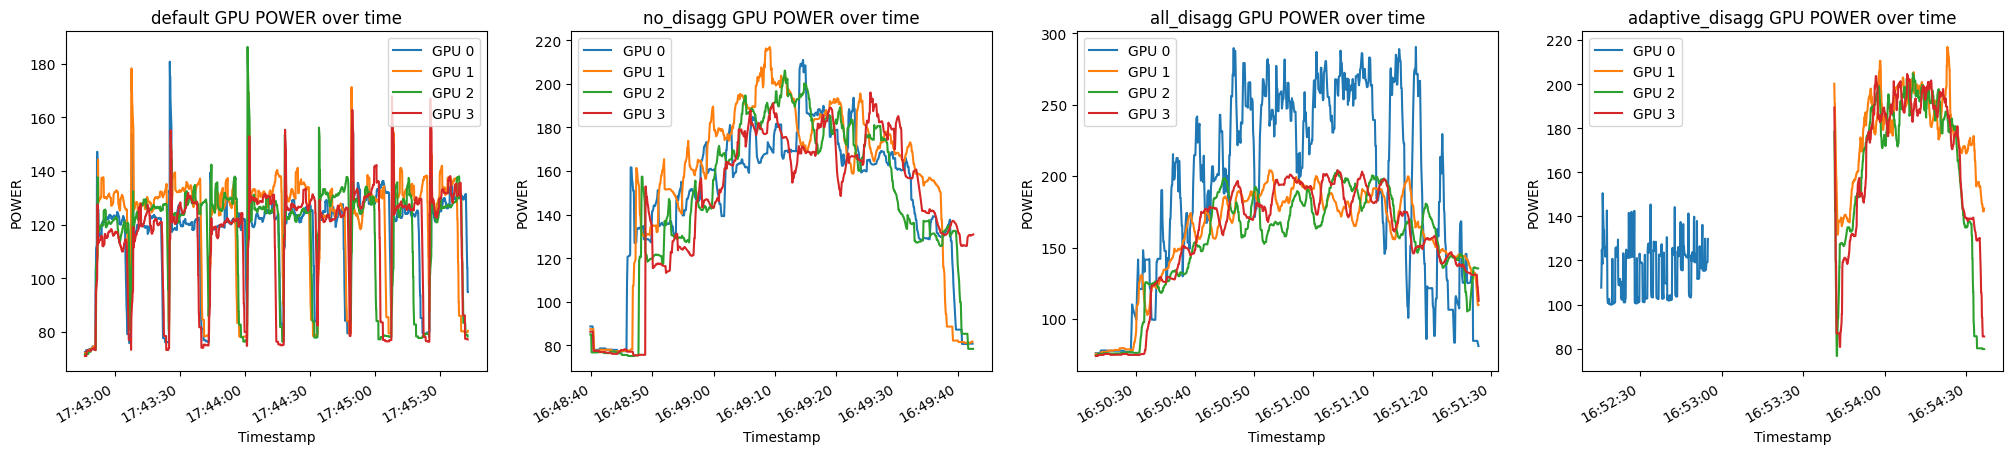

In [128]:
fig, axs = plt.subplots(1, len(policies), figsize=(25, 5))
for ax, policy in zip(axs, policies):
    for i, df in gpu_dfs[policy].items():
        df["POWER"].plot(ax=ax, label=f"GPU {i}")
    ax.legend()
    ax.set_title(f"{policy} GPU POWER over time")
    ax.set_xlabel("Timestamp")
    ax.set_ylabel("POWER")

In [36]:
df['gpu_id'].unique()
# df.head()

array([0, 1, 2, 3])

In [9]:
for policy in policies:
    fn = PAARSE_DISPATCH[policy]
    fn(Qwen3_06B_dir, 3)
    fn(Qwen3_06B_300_200_dir, 3)

In [11]:
def plot(normalized_e2e_latency_maps, normalized_first_iter_ttfts, normalized_rest_iter_ttfts, normalized_p99_tbts, normalized_max_tbts):
    fig, axs = plt.subplots(1, 4, figsize=(25, 5))
    # Plot normalized results
    p99_e2e_latencies = {
        policy: np.percentile(list(normalized_e2e_latency_maps[policy].values()), 99)
        for policy in policies[1:]
    }
    x = np.arange(5)
    xlabels = ['p99 e2e latency', 'First Iteration TTFT', 'Rest Iteration TTFT', 'p99 TBT', 'Max TBT']
    data = [
        [
            p99_e2e_latencies[policy],
            stats.hmean(normalized_first_iter_ttfts[policy]), 
            stats.hmean(normalized_rest_iter_ttfts[policy]), 
            normalized_p99_tbts[policy], 
            normalized_max_tbts[policy]
        ]
        for policy in policies[1:]
    ]
    for i, policy in enumerate(policies[1:]):
        axs[0].bar(x-0.2+i*0.2, data[i], label=policy, width=0.2)
    axs[0].set_title('Normalized First Iteration TTFT')
    axs[0].set_xticks(x, xlabels)
    axs[0].legend()

    # Plot normalized e2e latency maps
    x = np.arange(200)
    data = [
        [
            normalized_e2e_latency_maps[policy][index]
            for index in all_iter_indexes
        ]
        for policy in policies[1:]
    ]
    for i, policy in enumerate(policies[1:]):
        axs[1].scatter(x, data[i], label=policy)
        # axs[1].bar(x-0.2+i*0.2, data[i], label=policy, width=0.2)
    axs[1].set_title('Normalized E2E Latency Maps')
    axs[1].legend()

    # Plot first iteration ttfts
    x = np.arange(40)
    for policy in policies[1:]:
        axs[2].scatter(x, normalized_first_iter_ttfts[policy], label=policy)
    axs[2].legend()
    axs[2].set_title('Normalized First Iteration TTFT')
    axs[2].set_xlabel('Conversation Index')
    axs[2].set_ylabel('Normalized TTFT')

    # Plot rest iteration ttfts
    x = np.arange(160)
    for policy in policies[1:]:
        axs[3].scatter(x, normalized_rest_iter_ttfts[policy], label=policy)
    axs[3].legend()
    axs[3].set_title('Normalized Rest Iteration TTFT')
    axs[3].set_xlabel('Conversation Index')
    axs[3].set_ylabel('Normalized TTFT')


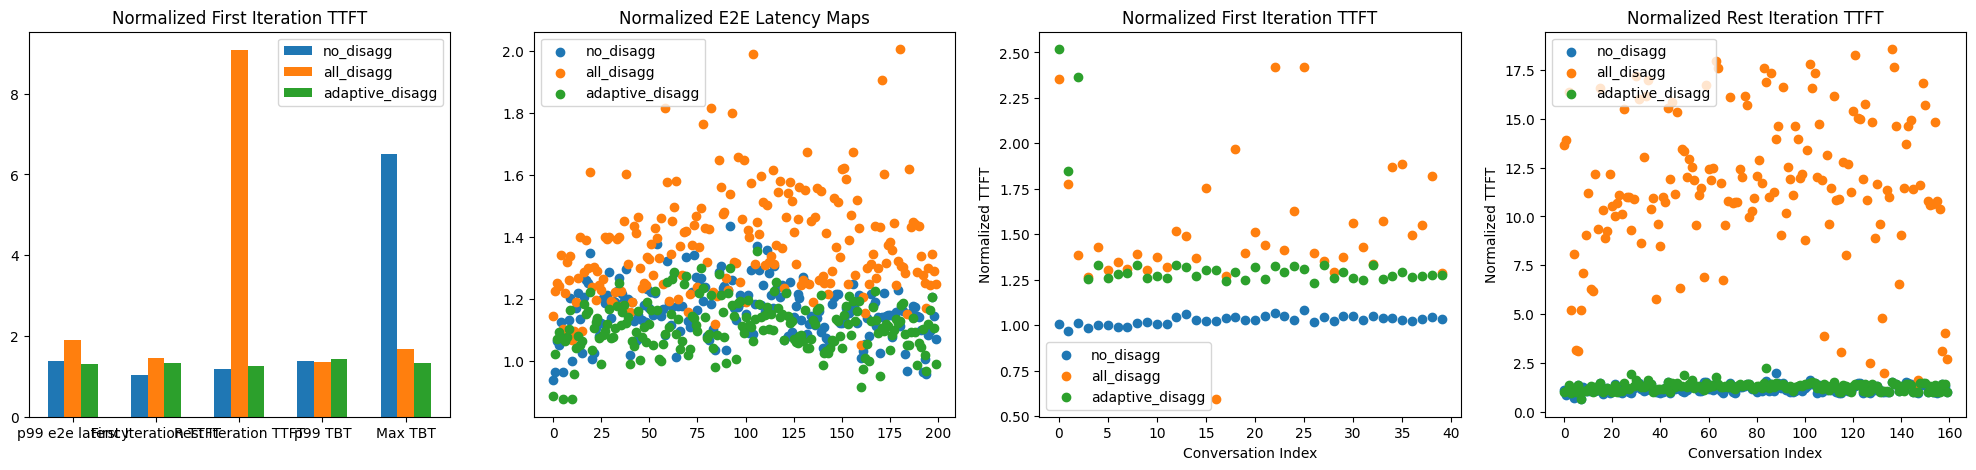

In [12]:
latency_maps = load_latency_maps(Qwen3_06B_dir)
e2e_latency_maps, normalized_e2e_latency_maps = load_e2e_latency_maps(Qwen3_06B_dir)
normalized_first_iter_ttfts, normalized_rest_iter_ttfts, normalized_p99_tbts, normalized_max_tbts = data_from_latency_maps(latency_maps)
plot(normalized_e2e_latency_maps, normalized_first_iter_ttfts, normalized_rest_iter_ttfts, normalized_p99_tbts, normalized_max_tbts)

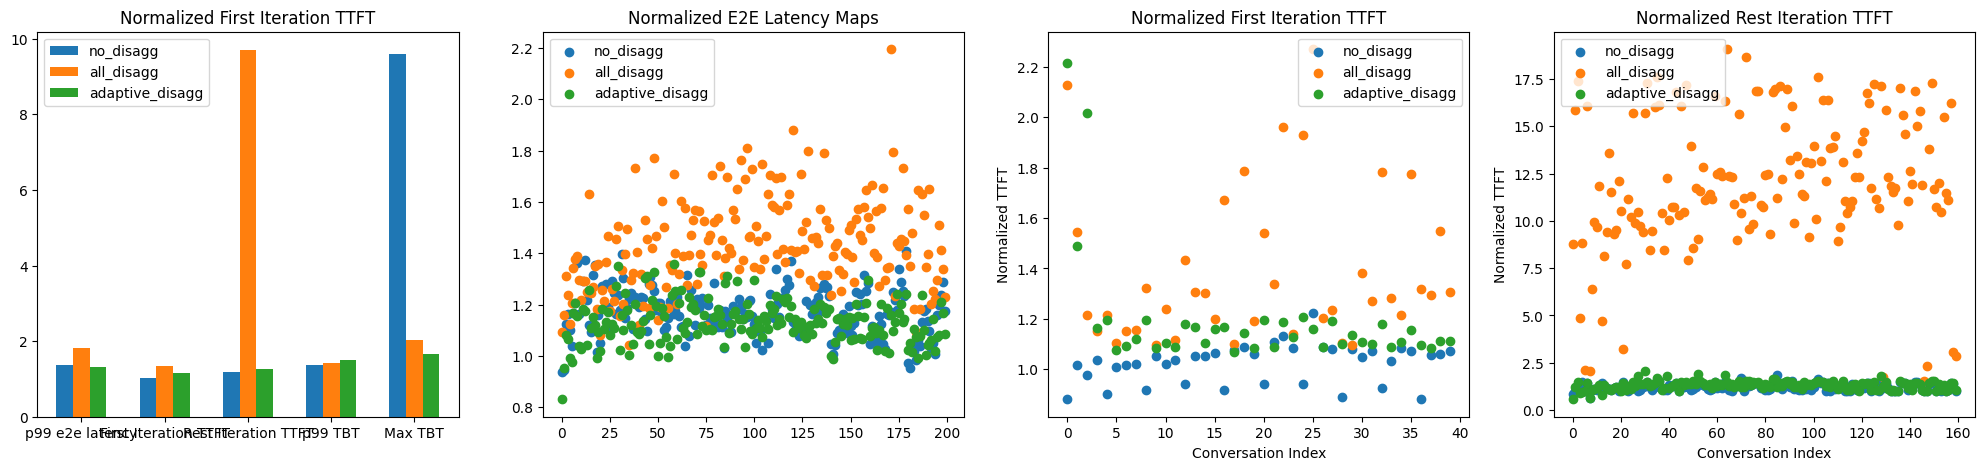

In [13]:
latency_maps = load_latency_maps(Qwen3_06B_300_200_dir)
e2e_latency_maps, normalized_e2e_latency_maps = load_e2e_latency_maps(Qwen3_06B_300_200_dir)
normalized_first_iter_ttfts, normalized_rest_iter_ttfts, normalized_p99_tbts, normalized_max_tbts = data_from_latency_maps(latency_maps)
plot(normalized_e2e_latency_maps, normalized_first_iter_ttfts, normalized_rest_iter_ttfts, normalized_p99_tbts, normalized_max_tbts)